In [2]:
import json

config_path = "../config/config2.json"
with open(config_path, 'r') as file:
        lora_configs = json.load(file)

task_names = []
for adapter in lora_configs:
    task_names.append(adapter['model_name'])
print(task_names)
        

['sst2', 'cb', 'multirc', 'wnli', 'squad_v2', 'web_nlg_en', 'definite_pronoun_resolution', 'wmt16_translate_tren', 'wmt16_translate_deen', 'squad_v1', 'dart', 'cosmos_qa', 'mnli_matched', 'anli_r3', 'e2e_nlg', 'anli_r2', 'natural_questions', 'paws_wiki', 'wmt16_translate_ruen', 'glue_qqp', 'story_cloze', 'openbookqa', 'yelp_polarity_reviews', 'arc_easy', 'wmt16_translate_fien', 'anli_r1', 'mnli_mismatched', 'imdb_reviews', 'wmt16_translate_roen', 'common_gen', 'snli', 'sentiment140', 'piqa', 'wmt14_enfr', 'wsc', 'arc_challenge', 'copa', 'qnli', 'glue_mrpc', 'bool_q', 'hellaswag', 'wmt16_translate_csen', 'rte', 'drop', 'record', 'stsb', 'trivia_qa', 'para_crawl_enes']


In [3]:
# Print all task names to identify the correct names for mapping
print("All task names in the dataset:")
for i, name in enumerate(task_names):
    print(f"{i}: {name}")
    
# Look for potential matches for the missing ones
print("\n\nSearching for potential matches:")
missing = ['glue_cola', 'boolq', 'wmt16_en_ro', 'wmt16_en_de', 'wmt16_en_fi', 
           'wmt16_en_cs', 'wmt16_ro_en', 'wmt14_fr_en', 'wmt16_de_en']
for missing_name in missing:
    print(f"\nSearching for '{missing_name}':")
    for name in task_names:
        if any(part in name.lower() for part in missing_name.split('_')):
            print(f"  Possible match: {name}")

All task names in the dataset:
0: sst2
1: cb
2: multirc
3: wnli
4: squad_v2
5: web_nlg_en
6: definite_pronoun_resolution
7: wmt16_translate_tren
8: wmt16_translate_deen
9: squad_v1
10: dart
11: cosmos_qa
12: mnli_matched
13: anli_r3
14: e2e_nlg
15: anli_r2
16: natural_questions
17: paws_wiki
18: wmt16_translate_ruen
19: glue_qqp
20: story_cloze
21: openbookqa
22: yelp_polarity_reviews
23: arc_easy
24: wmt16_translate_fien
25: anli_r1
26: mnli_mismatched
27: imdb_reviews
28: wmt16_translate_roen
29: common_gen
30: snli
31: sentiment140
32: piqa
33: wmt14_enfr
34: wsc
35: arc_challenge
36: copa
37: qnli
38: glue_mrpc
39: bool_q
40: hellaswag
41: wmt16_translate_csen
42: rte
43: drop
44: record
45: stsb
46: trivia_qa
47: para_crawl_enes


Searching for potential matches:

Searching for 'glue_cola':
  Possible match: glue_qqp
  Possible match: glue_mrpc

Searching for 'boolq':

Searching for 'wmt16_en_ro':
  Possible match: web_nlg_en
  Possible match: definite_pronoun_resolution
  Possibl

In [4]:
# Define the order from the picture (by domain grouping)
desired_order = [
    'natural_questions', 'arc_easy', 'arc_challenge', 'trivia_qa', 'story_cloze', 'piqa', 'copa', 'hellaswag',
    'definite_pronoun_resolution', 'wsc', 'cb', 'wnli', 'anli_r1', 'anli_r2', 'anli_r3', 'mnli_matched',
    'mnli_mismatched', 'snli', 'qnli', 'rte', 'paws_wiki', 'glue_qqp', 'glue_mrpc', 'stsb',
    'cosmos_qa', 'record', 'multirc', 'squad_v2', 'squad_v1', 'openbookqa',
    'bool_q', 'drop', 'sst2', 'yelp_polarity_reviews', 'imdb_reviews', 'sentiment140',
    'web_nlg_en', 'dart', 'e2e_nlg', 'common_gen', 'para_crawl_enes',
    'wmt16_translate_roen', 'wmt16_translate_deen', 'wmt16_translate_fien', 'wmt16_translate_csen',
    'wmt16_translate_ruen', 'wmt14_enfr', 'wmt16_translate_tren'
]

group_sizes = [4, 4, 2, 10, 4, 2, 6, 4, 4, 8]

# Create a mapping function that handles slight name variations
def match_task_name(name, candidates):
    """Find the best matching candidate for a task name."""
    name_lower = name.lower().replace('-', '_').replace(' ', '_')
    for candidate in candidates:
        candidate_lower = candidate.lower().replace('-', '_').replace(' ', '_')
        if name_lower == candidate_lower or name_lower in candidate_lower or candidate_lower in name_lower:
            return candidate
    return None

# Create index mapping
index_mapping = []
for desired_name in desired_order:
    matched_idx = None
    for idx, current_name in enumerate(task_names):
        if match_task_name(desired_name, [current_name]):
            matched_idx = idx
            break
    if matched_idx is not None:
        index_mapping.append(matched_idx)
    else:
        print(f"Warning: Could not find match for '{desired_name}' in task_names")

print(f"Original order has {len(task_names)} tasks")
print(f"Desired order has {len(desired_order)} tasks")
print(f"Matched {len(index_mapping)} tasks")
print(f"\nIndex mapping: {index_mapping}")

Original order has 48 tasks
Desired order has 48 tasks
Matched 48 tasks

Index mapping: [16, 23, 35, 46, 20, 32, 36, 40, 6, 34, 1, 3, 25, 15, 13, 12, 26, 30, 37, 42, 17, 19, 38, 45, 11, 44, 2, 4, 9, 21, 39, 43, 0, 22, 27, 31, 5, 10, 14, 29, 47, 28, 8, 24, 41, 18, 33, 7]


In [5]:
# Create abbreviation mapping
abbreviation_map = {
    'natural_questions': 'natural',
    'arc_easy': 'arc_e',
    'arc_challenge': 'arc_c',
    'trivia_qa': 'trivia',
    'story_cloze': 'story',
    'piqa': 'piqa',
    'copa': 'copa',
    'hellaswag': 'hella',
    'definite_pronoun_resolution': 'defpro',
    'wsc': 'wsc',
    'cb': 'cb',
    'wnli': 'wnli',
    'anli_r1': 'anli1',
    'anli_r2': 'anli2',
    'anli_r3': 'anli3',
    'mnli_matched': 'mnli_m',
    'mnli_mismatched': 'mnli_mm',
    'snli': 'snli',
    'qnli': 'qnli',
    'rte': 'rte',
    'paws_wiki': 'paws',
    'glue_qqp': 'qqp',
    'glue_mrpc': 'mrpc',
    'stsb': 'stsb',
    'cosmos_qa': 'cosmos',
    'record': 'record',
    'multirc': 'multirc',
    'squad_v2': 'sqd_v2',
    'squad_v1': 'sqd_v1',
    'openbookqa': 'obqa',
    'bool_q': 'bool',
    'drop': 'drop',
    'sst2': 'sst2',
    'yelp_polarity_reviews': 'yelp',
    'imdb_reviews': 'imdb',
    'sentiment140': 'sent140',
    'web_nlg_en': 'webnlg',
    'dart': 'dart',
    'e2e_nlg': 'e2e',
    'common_gen': 'cgen',
    'para_crawl_enes': 'para_es',
    'wmt16_translate_roen': 'ro-en',
    'wmt16_translate_deen': 'de-en',
    'wmt16_translate_fien': 'fi-en',
    'wmt16_translate_csen': 'cs-en',
    'wmt16_translate_ruen': 'ru-en',
    'wmt14_enfr': 'en-fr',
    'wmt16_translate_tren': 'tr-en'
}

# Function to abbreviate task names
def abbreviate_name(name):
    return abbreviation_map.get(name, name)

print("Abbreviation mapping created!")
print(f"Example: '{list(abbreviation_map.keys())[0]}' -> '{list(abbreviation_map.values())[0]}'")

Abbreviation mapping created!
Example: 'natural_questions' -> 'natural'


Group boundaries at positions: [ 4  8 10 20 24 26 32 36 40]


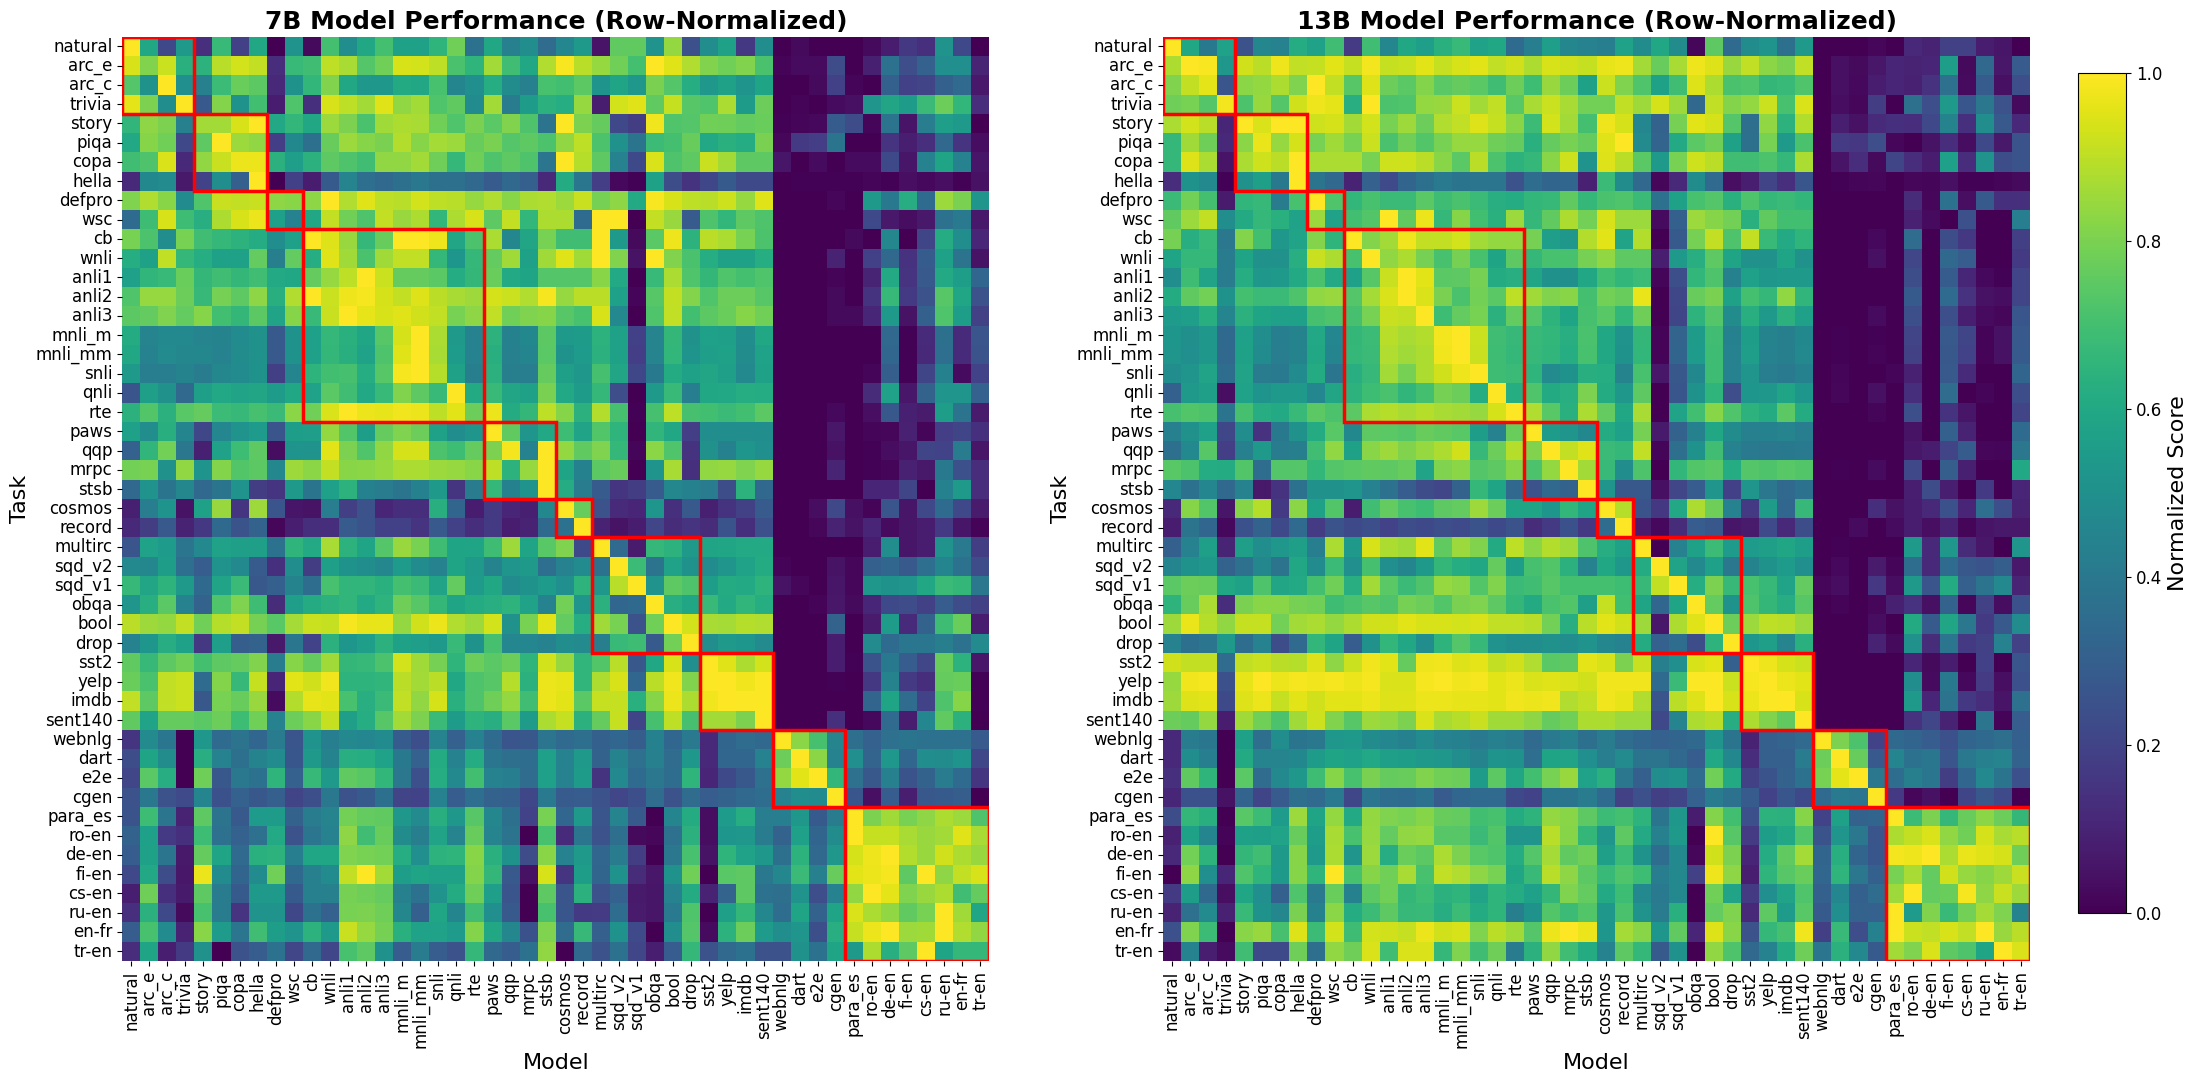

7B matrix shape: (48, 48)
13B matrix shape: (48, 48)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the performance matrices
perf_7b = np.load('../adapter_evaluation/model_performance_7b.npy', allow_pickle=True)
perf_13b = np.load('../adapter_evaluation/model_performance_13b.npy', allow_pickle=True)

# Convert to float if needed
perf_7b = perf_7b.astype(float)
perf_13b = perf_13b.astype(float)

# Reorder rows and columns according to the picture
if len(index_mapping) > 0:
    perf_7b = perf_7b[np.ix_(index_mapping, index_mapping)]
    perf_13b = perf_13b[np.ix_(index_mapping, index_mapping)]
    reordered_task_names = [task_names[i] for i in index_mapping]
else:
    reordered_task_names = task_names

# Abbreviate the task names
abbreviated_names = [abbreviate_name(name) for name in reordered_task_names]

# Normalize each row so the highest score is 1
perf_7b_norm = (perf_7b - perf_7b.min(axis=1, keepdims=True)) / (perf_7b.max(axis=1, keepdims=True) - perf_7b.min(axis=1, keepdims=True))
perf_13b_norm = (perf_13b - perf_13b.min(axis=1, keepdims=True)) / (perf_13b.max(axis=1, keepdims=True) - perf_13b.min(axis=1, keepdims=True))

# Calculate group boundaries
group_boundaries = np.cumsum(group_sizes)[:-1]  # Don't include the last boundary
print(f"Group boundaries at positions: {group_boundaries}")

# Create heatmaps with shared colorbar
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# 7B model heatmap
sns.heatmap(perf_7b_norm, ax=axes[0], cmap='viridis', 
            xticklabels=abbreviated_names, yticklabels=abbreviated_names,
            cbar=False, vmin=0, vmax=1)
axes[0].set_title('7B Model Performance (Row-Normalized)', fontsize=18, fontweight='bold')
axes[0].set_xlabel('Model', fontsize=16)
axes[0].set_ylabel('Task', fontsize=16)
axes[0].tick_params(axis='x', rotation=90, labelsize=12)
axes[0].tick_params(axis='y', rotation=0, labelsize=12)

# Add group boundary squares for 7B
from matplotlib.patches import Rectangle
start_pos = 0
for size in group_sizes:
    rect = Rectangle((start_pos, start_pos), size, size, 
                     linewidth=2.5, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)
    start_pos += size

# 13B model heatmap (also without colorbar)
im = sns.heatmap(perf_13b_norm, ax=axes[1], cmap='viridis', 
                 xticklabels=abbreviated_names, yticklabels=abbreviated_names,
                 cbar=False, vmin=0, vmax=1)
axes[1].set_title('13B Model Performance (Row-Normalized)', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Model', fontsize=16)
axes[1].set_ylabel('Task', fontsize=16)
axes[1].tick_params(axis='x', rotation=90, labelsize=12)
axes[1].tick_params(axis='y', rotation=0, labelsize=12)

# Add group boundary squares for 13B
start_pos = 0
for size in group_sizes:
    rect = Rectangle((start_pos, start_pos), size, size, 
                     linewidth=2.5, edgecolor='red', facecolor='none')
    axes[1].add_patch(rect)
    start_pos += size

# Add a shared colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
cbar = fig.colorbar(axes[1].collections[0], cax=cbar_ax, label='Normalized Score')
cbar.set_label('Normalized Score', fontsize=16)
cbar.ax.tick_params(labelsize=12)

plt.show()

print(f"7B matrix shape: {perf_7b.shape}")
print(f"13B matrix shape: {perf_13b.shape}")

In [ ]:
import pandas as pd

# Create CSV for 7B model - unnormalized
columns_7b = ['task_name']
for name in abbreviated_names:
    columns_7b.append(name)

data_7b = []
for i, task_name in enumerate(abbreviated_names):
    row = [task_name]
    row.extend(perf_7b[i, :])
    data_7b.append(row)

df_7b = pd.DataFrame(data_7b, columns=columns_7b)
df_7b.to_csv('validation_performance_7b.csv', index=False)
print(f"Saved validation_performance_7b.csv with shape: {df_7b.shape}")

# Create CSV for 7B model - normalized
columns_7b_norm = ['task_name']
for name in abbreviated_names:
    columns_7b_norm.append(name)

data_7b_norm = []
for i, task_name in enumerate(abbreviated_names):
    row = [task_name]
    row.extend(perf_7b_norm[i, :])
    data_7b_norm.append(row)

df_7b_norm = pd.DataFrame(data_7b_norm, columns=columns_7b_norm)
df_7b_norm.to_csv('validation_performance_7b_norm.csv', index=False)
print(f"Saved validation_performance_7b_norm.csv with shape: {df_7b_norm.shape}")

# Create CSV for 13B model - unnormalized
columns_13b = ['task_name']
for name in abbreviated_names:
    columns_13b.append(name)

data_13b = []
for i, task_name in enumerate(abbreviated_names):
    row = [task_name]
    row.extend(perf_13b[i, :])
    data_13b.append(row)

df_13b = pd.DataFrame(data_13b, columns=columns_13b)
df_13b.to_csv('validation_performance_13b.csv', index=False)
print(f"Saved validation_performance_13b.csv with shape: {df_13b.shape}")

# Create CSV for 13B model - normalized
columns_13b_norm = ['task_name']
for name in abbreviated_names:
    columns_13b_norm.append(name)

data_13b_norm = []
for i, task_name in enumerate(abbreviated_names):
    row = [task_name]
    row.extend(perf_13b_norm[i, :])
    data_13b_norm.append(row)

df_13b_norm = pd.DataFrame(data_13b_norm, columns=columns_13b_norm)
df_13b_norm.to_csv('validation_performance_13b_norm.csv', index=False)
print(f"Saved validation_performance_13b_norm.csv with shape: {df_13b_norm.shape}")

print("\n✓ All 4 CSV files created successfully!")
print(f"Each file contains {len(abbreviated_names)} rows (tasks) and {len(abbreviated_names)+1} columns")

Saved validation_performance_7b.csv with shape: (48, 97)
Saved validation_performance_13b.csv with shape: (48, 97)

CSV files created successfully!
Each file contains 48 rows (tasks)
Column structure: task_name | 48 perf columns | 48 perf_norm columns
